# Comparação das técnicas de NER

Três abordagens foram treinadas no mesmo split (240 treino / 60 teste, seed=42) do dataset
`cellphone.ibyte.json` anotado em `data/annotations/cellphone.ibyte.jsonl`:

1. **spaCy** (`notebooks/01_spacy_ner.ipynb`): pipeline `ner` em branco, treinado do zero.
2. **CRF** (`notebooks/02_crf_ner.ipynb`): Conditional Random Field com features artesanais.
3. **BERTimbau** (`notebooks/03_bertimbau_ner.ipynb`): fine-tuning de `neuralmind/bert-base-portuguese-cased`.

As métricas de cada técnica foram salvas em `notebooks/results/*_metrics.json` e são carregadas
aqui só para gerar a comparação final.

In [1]:
import sys
sys.path.insert(0, "../scripts")
from compare_results import build_overall_table, build_per_tag_table

overall = build_overall_table()
overall

,precision,recall,f1,support
tecnica,,,,
bertimbau,0.914384,0.917526,0.915952,291
crf,0.921986,0.893471,0.907504,291
spacy,0.881533,0.869416,0.875433,291


## Resultado geral

F1 micro (seqeval, esquema IOB2) no conjunto de teste (60 títulos, 291 entidades).

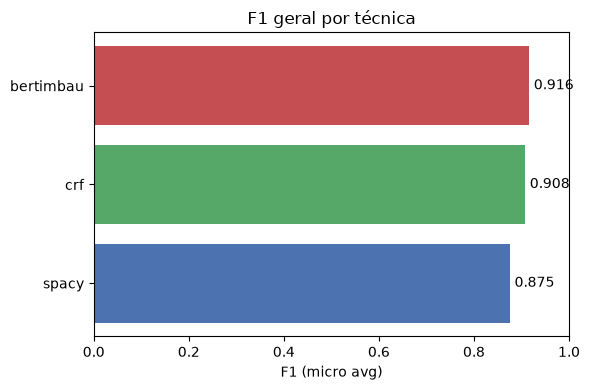

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
overall_sorted = overall.sort_values("f1")
ax.barh(overall_sorted.index, overall_sorted["f1"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlabel("F1 (micro avg)")
ax.set_xlim(0, 1)
for i, v in enumerate(overall_sorted["f1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
ax.set_title("F1 geral por técnica")
plt.tight_layout()
plt.savefig("results/f1_geral.png", dpi=120)
plt.show()

## F1 por entidade (tag)

Onde cada técnica se sai melhor/pior, por tipo de entidade.

In [3]:
per_tag = build_per_tag_table()
per_tag.style.background_gradient(cmap="RdYlGn", axis=1, vmin=0.6, vmax=1.0)

,spacy,crf,bertimbau
TIPO,0.764706,0.910891,0.942308
MARCA,0.960000,0.950820,0.951613
MODELO,0.850394,0.850394,0.844444
MEMORIA,0.955224,0.985075,0.985075
RAM,0.928571,1.000000,1.000000
COR,0.883721,0.860465,0.904762
TELA,0.790698,0.857143,0.829268


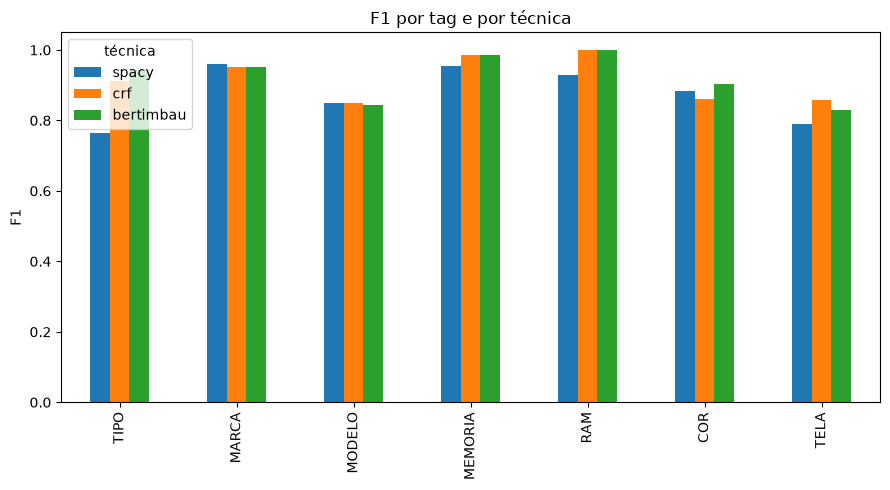

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
per_tag.plot(kind="bar", ax=ax)
ax.set_ylabel("F1")
ax.set_ylim(0, 1.05)
ax.set_title("F1 por tag e por técnica")
ax.legend(title="técnica")
plt.tight_layout()
plt.savefig("results/f1_por_tag.png", dpi=120)
plt.show()

## Discussão

- **BERTimbau** teve o melhor F1 geral (0.916), puxado por TIPO e COR, entidades onde o
  contexto semântico das subpalavras ajuda a desambiguar (ex: "Case" vs "Capa" como TIPO).
- **CRF** ficou muito próximo (0.9075), superando as outras duas em MEMORIA e RAM, tags
  com formato bem regular (`\dGB`, `\dGB RAM`) onde as features artesanais (dígito, sufixo,
  contexto de -1/+1 token) já capturam quase todo o sinal necessário sem precisar de um
  modelo pesado.
- **spaCy** (treinado do zero, sem pesos pré-treinados) ficou atrás nas tags mais dependentes
  de vocabulário livre (TIPO, TELA), o que é esperado: sem embeddings pré-treinados, aprender
  a generalizar variações lexicais só com 240 exemplos é mais difícil.
- Em todas as três técnicas, `MODELO` é a tag mais difícil (F1 entre 0.84 e 0.85): nomes de
  modelo têm alta variedade lexical (ex: "iPhone 14 Pro Max", "Ms45S Sênior", "Redmi Note 8
  Pro") e fronteiras ambíguas com `TIPO`/`MARCA` em alguns títulos.

Dado o tamanho pequeno do conjunto anotado (300 títulos), a diferença entre as três técnicas
(0.875 a 0.916 de F1) é relativamente pequena. Para produção, o CRF é o melhor custo-benefício
(quase o mesmo F1 do BERTimbau, ordens de magnitude mais rápido para treinar e rodar); o
BERTimbau vale a pena se o dataset anotado crescer bastante, onde o ganho de generalização
semântica tende a aumentar.